# Crossover / Intersection Between Two Sequences

## Algorithm

1. **Generate one random origin pattern**, $\xi^0$. This is *not* done by
   `KuramotoNetwork` -- the network only owns config/omega/simulate/diagnostics;
   pattern generation lives in free functions (`generate_sequence`, `corrupt_phase`),
   independent of the network object.
2. **Draw 4 seeds at random** from a seed pool (a fresh draw every trial, not fixed).
3. **Mutate the origin independently 4 times**, one per seed (each mutation is its own
   fresh corruption of $\xi^0$, not chained from one another). Build two length-3
   sequences with the origin as the shared centre pattern:
   $$A: M_1 \rightarrow \xi^0 \rightarrow M_2 \qquad B: M_3 \rightarrow \xi^0 \rightarrow M_4$$
4. **Combine A and B into one `MultiSequence`** and run `simulate()` on it.
   `simulate()` for a `MultiSequence` is *not* a different code path from a single
   `Sequence` -- `MultiSequence.xi()`/`.xi_next()` just concatenate every member's own
   arrays into one combined array, which is fed into the exact same ODE/SDE kernel a
   lone sequence uses. It's one shared energy landscape; the kernel has no notion of
   which stored pattern belongs to which sequence.
5. **Repeat for `M` independent trials** (fresh random seeds each time). Each trial
   runs two simulations -- one cued from $A[0]$, one from $B[0]$ -- with nonzero
   `frequency_std` (omega must be present, or the exact-cue degeneracy freezes the
   dynamics -- see earlier findings this session). Plot the overlap and the
   per-sequence overlap breakdown for both. Decode with `decode_sequence_online`,
   take only the first 3 retrieved labels ("cut at 3"), and score +1 if they exactly
   match that sequence's own expected order, else 0. Print the average success rate
   across all `2*M` cueing attempts.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

import kuramoto_library2 as krm

import matplotlib.pyplot as plt

In [2]:
CONFIG = dict(
    dt=0.05,
    T=30.0,
    frequency_std=0.03,
    phase_noise=0.01,
    d=3,
    corruption_rate=0.2,
    tolerance=0.4,
    mode="ode",
)

N = 40
M = 5
MARGIN = 0.01
SEED_POOL = 10_000
master_rng = np.random.default_rng(0)

## Build one crossover trial

In [3]:
def make_crossover_multisequence(N, corruption_rate, origin_seed, mutation_seeds):
    rng = np.random.default_rng(origin_seed)
    origin = rng.choice([0.0, np.pi], size=N)

    M1, M2, M3, M4 = [
        krm.corrupt_phase(origin, corruption_rate, np.random.default_rng(s))
        for s in mutation_seeds
    ]

    def build(name, patterns):
        vectors = krm.VectorSequence(L=len(patterns), N=N)
        for i, pattern in enumerate(patterns):
            vectors[i] = pattern
        return krm.Sequence(name=name, vectors=vectors)

    multi = krm.MultiSequence()
    multi.add(build("A", [M1, origin, M2]))
    multi.add(build("B", [M3, origin, M4]))
    return multi


def run_trial(net, rng):
    origin_seed = int(rng.integers(SEED_POOL))
    mutation_seeds = rng.choice(SEED_POOL, size=4, replace=False).tolist()
    multi = make_crossover_multisequence(N, CONFIG["corruption_rate"], origin_seed, mutation_seeds)

    result_A = net.simulate(multi, cue=multi["A"], cue_idx=0)
    result_B = net.simulate(multi, cue=multi["B"], cue_idx=0)

    retrieved_A = net.decode_sequence_online(result_A, multi, margin=MARGIN)[:3]
    retrieved_B = net.decode_sequence_online(result_B, multi, margin=MARGIN)[:3]

    success_A = retrieved_A == multi["A"].labels()
    success_B = retrieved_B == multi["B"].labels()

    return multi, result_A, result_B, retrieved_A, retrieved_B, success_A, success_B

## Run M trials

trial 0: A retrieved=[('A', 0), ('A', 1)] success=False
trial 0: B retrieved=[('B', 0), ('A', 1)] success=False


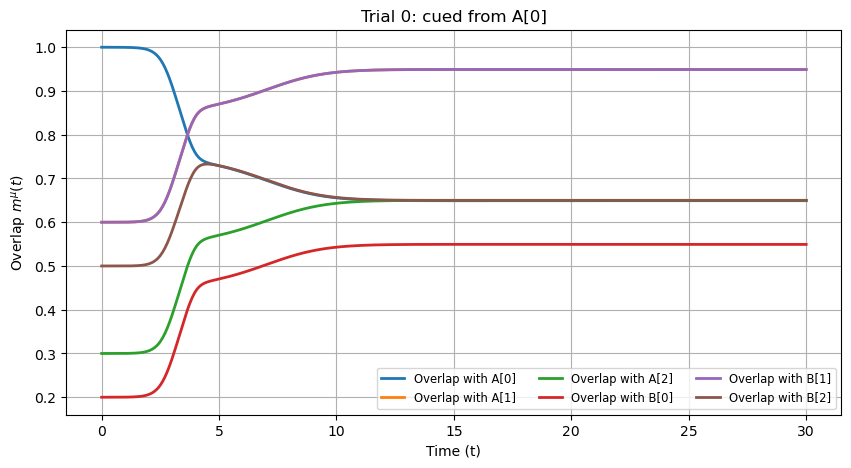

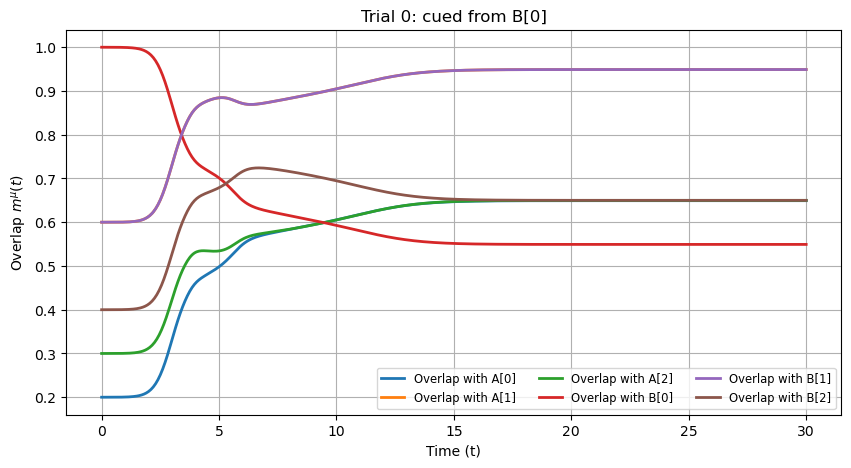

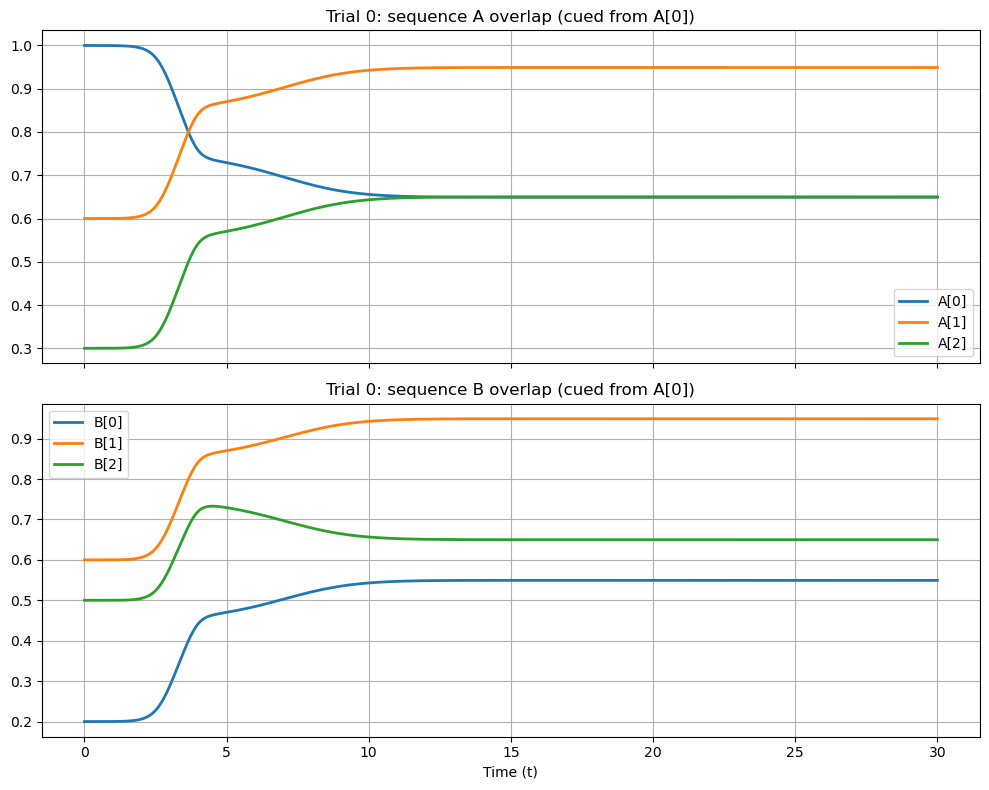

trial 1: A retrieved=[('A', 0), ('A', 1), ('A', 2)] success=True
trial 1: B retrieved=[('B', 0), ('A', 1)] success=False


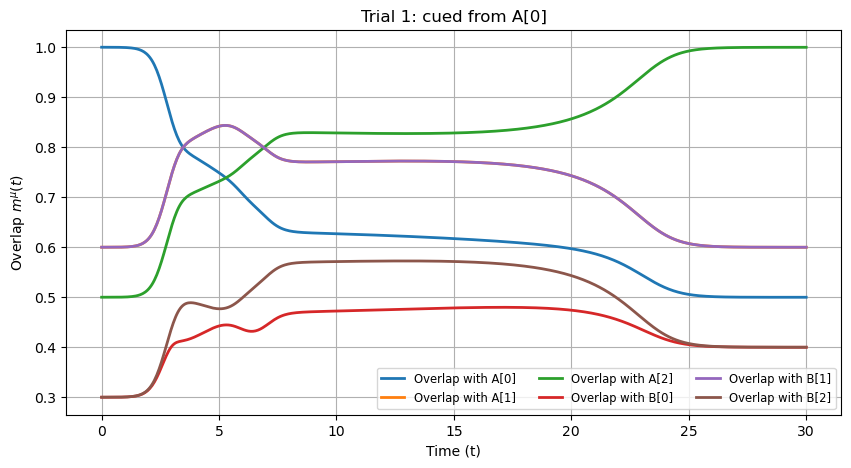

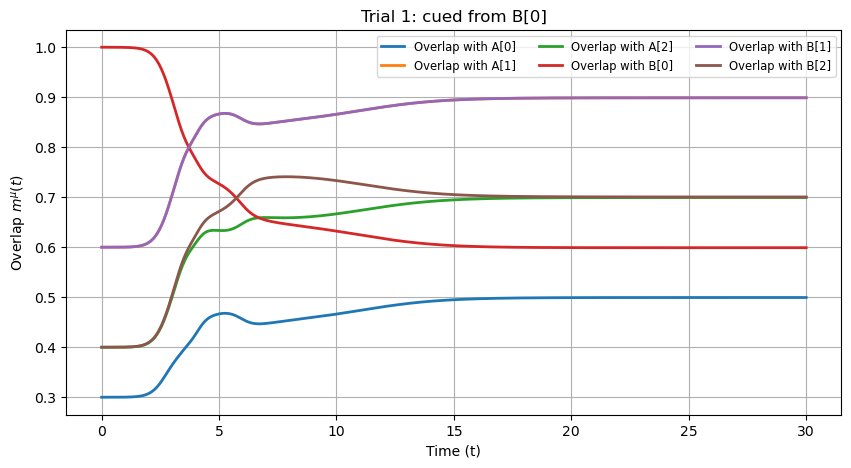

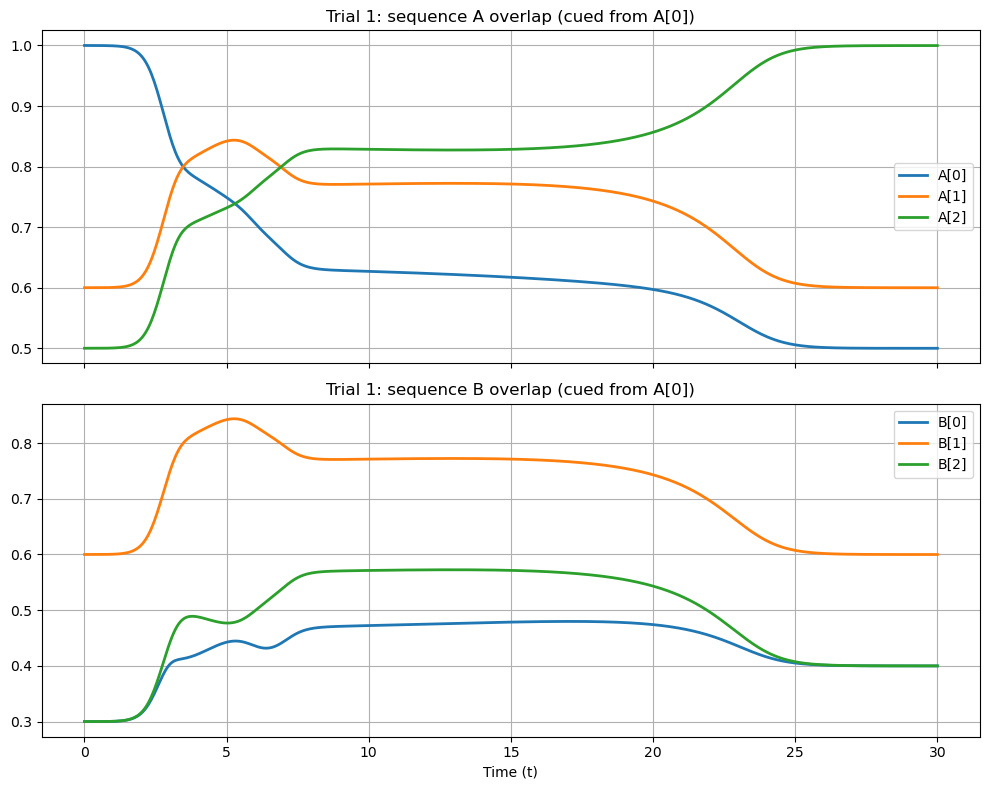

trial 2: A retrieved=[('A', 0), ('A', 1), ('A', 2)] success=True
trial 2: B retrieved=[('B', 0), ('B', 2)] success=False


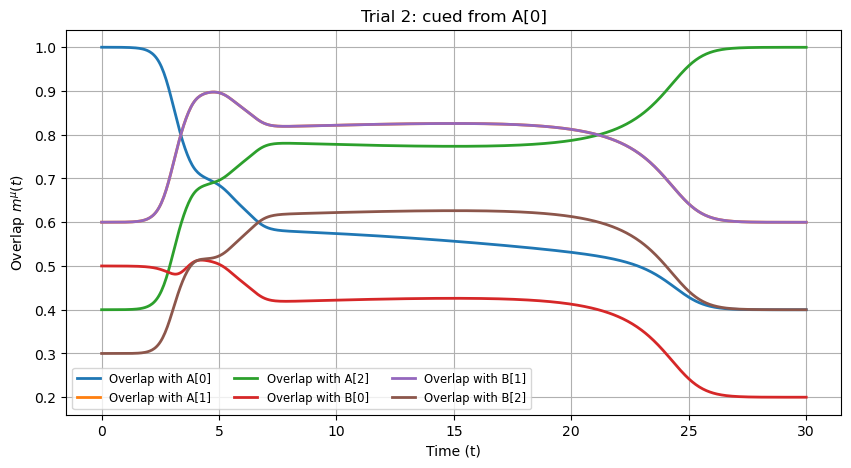

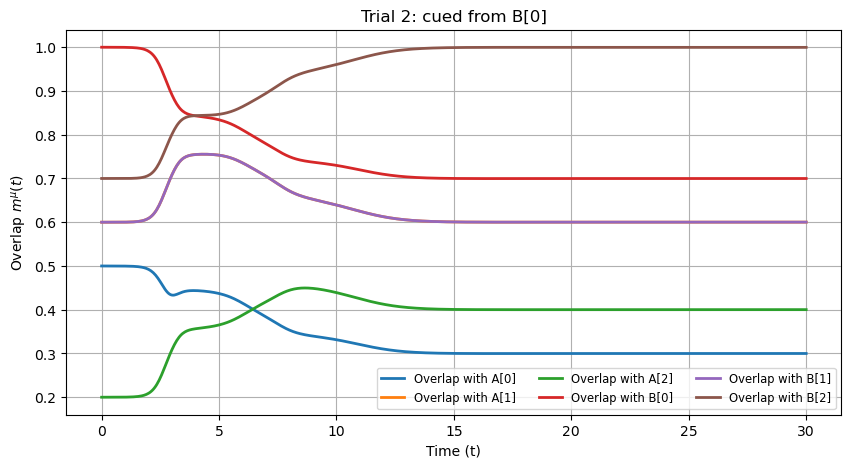

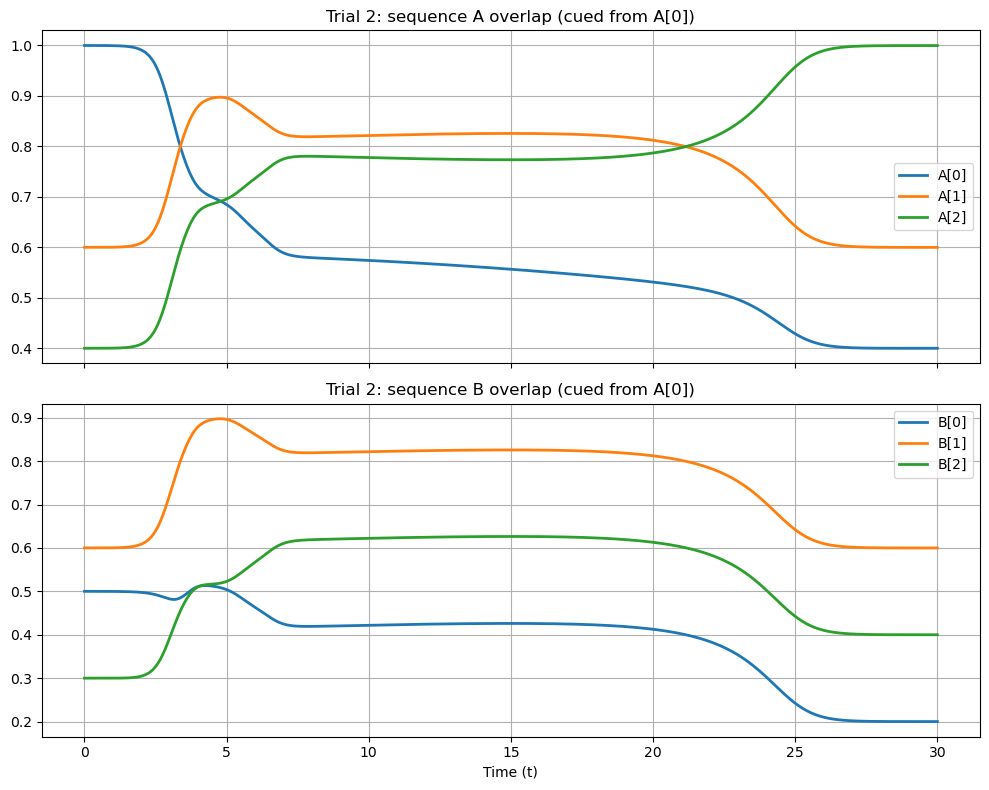

trial 3: A retrieved=[('A', 0), ('A', 1)] success=False
trial 3: B retrieved=[('B', 0), ('A', 1)] success=False


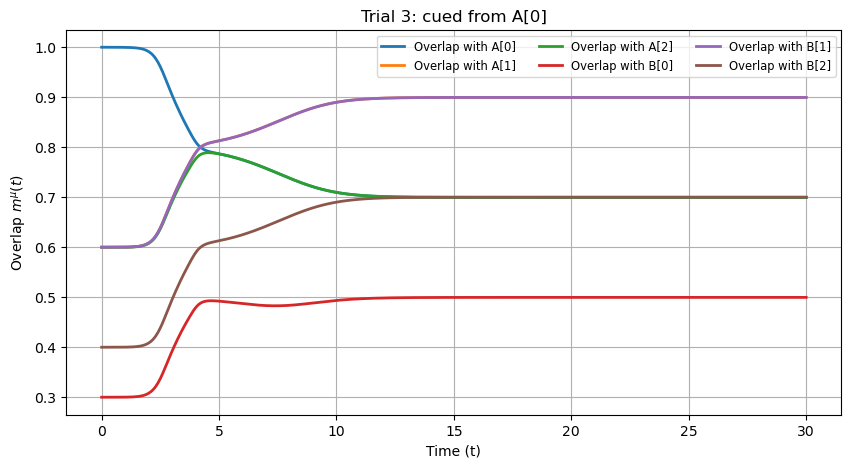

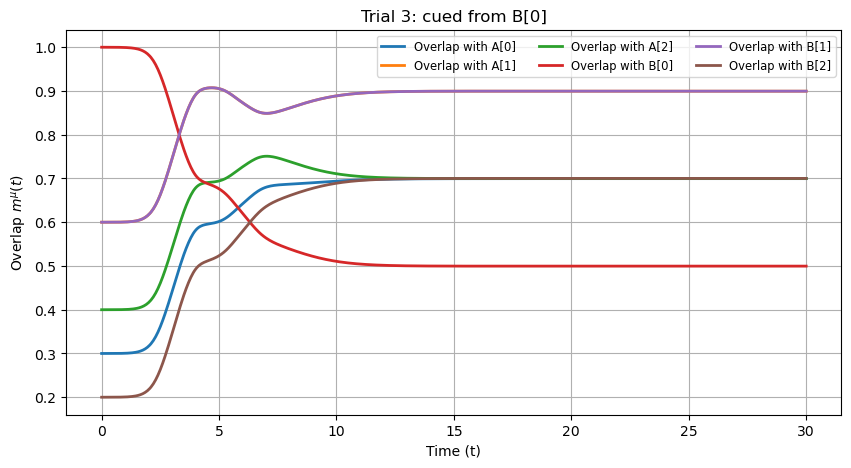

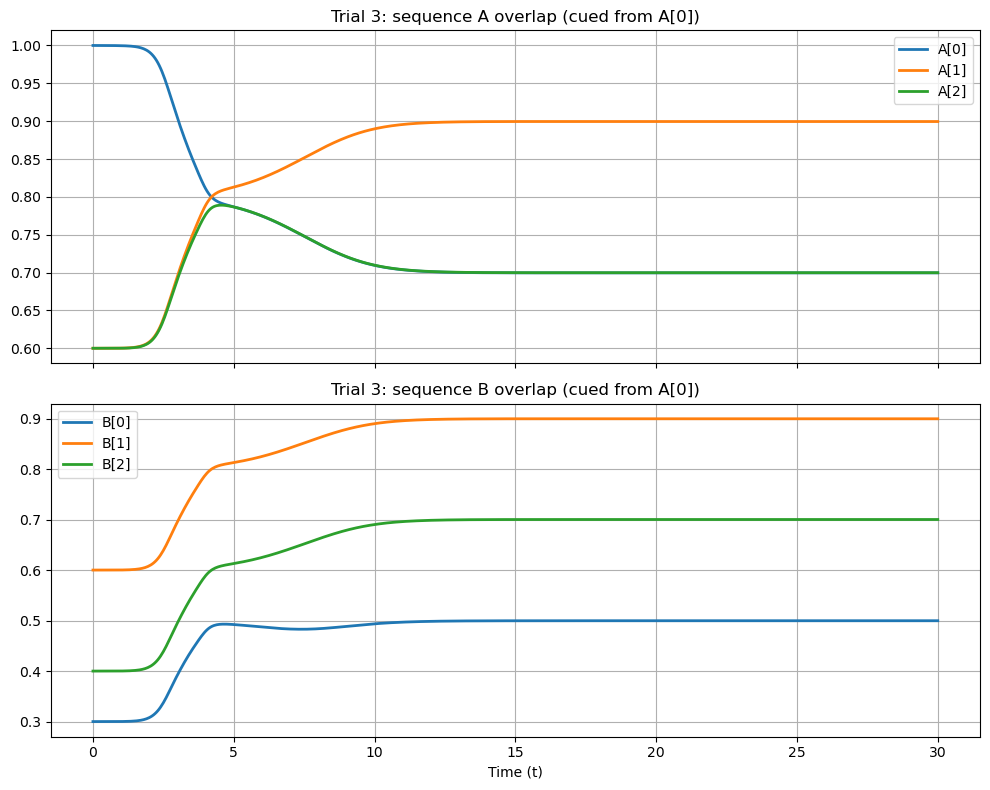

trial 4: A retrieved=[('A', 0), ('A', 1)] success=False
trial 4: B retrieved=[('B', 0), ('A', 1), ('B', 2)] success=False


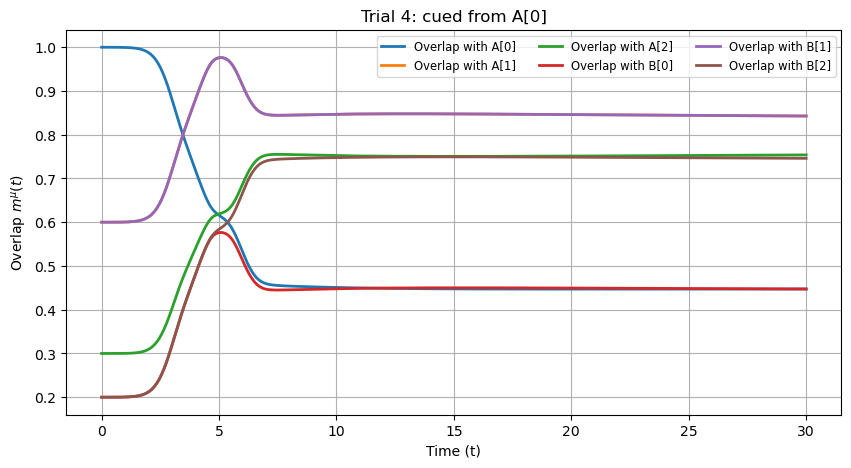

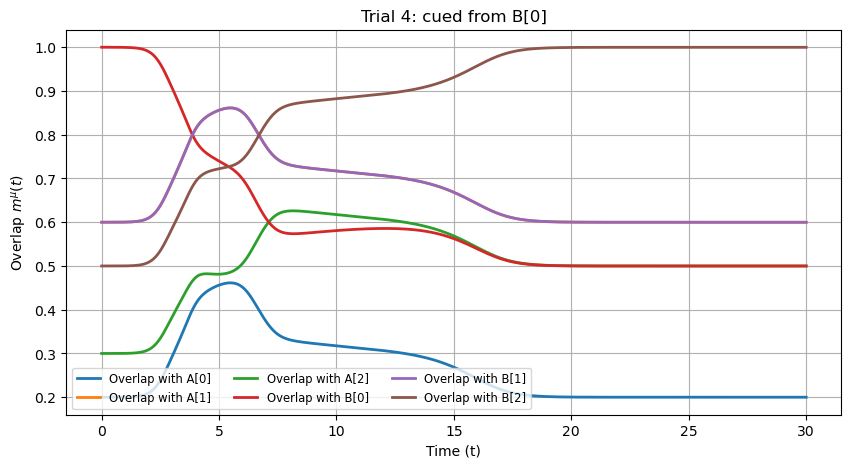

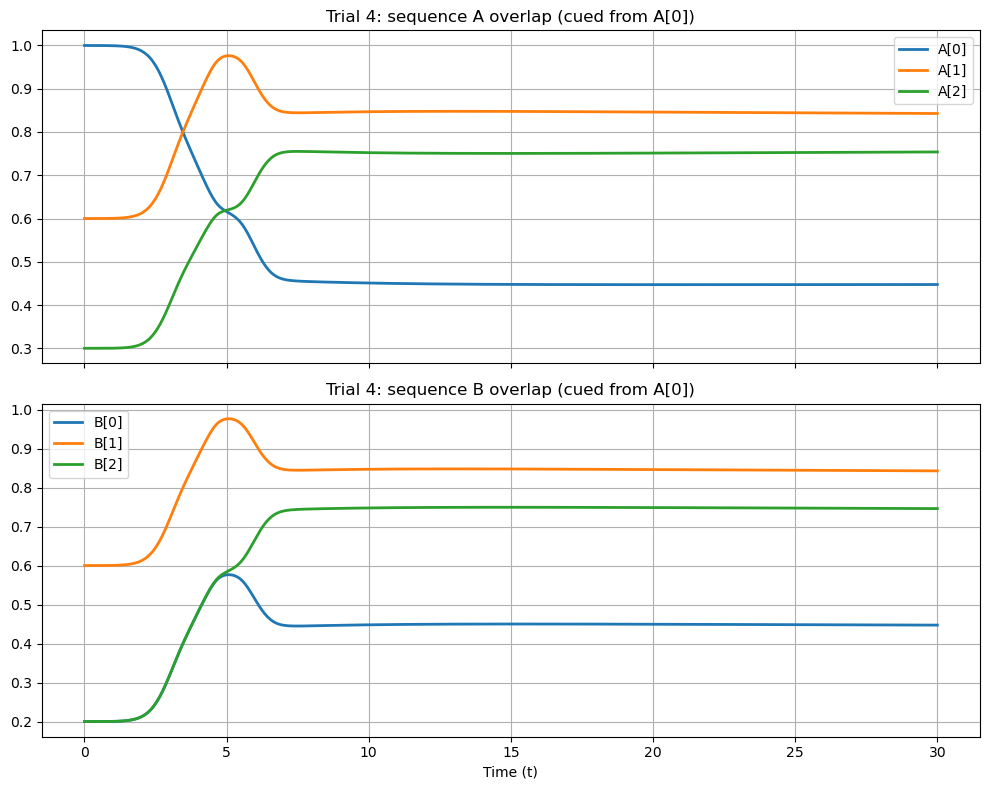

average success rate: 0.2


In [4]:
net = krm.KuramotoNetwork(N=N, seed=10, **CONFIG)

successes = []
for trial in range(M):
    multi, result_A, result_B, retrieved_A, retrieved_B, success_A, success_B = run_trial(net, master_rng)
    successes += [success_A, success_B]

    print(f"trial {trial}: A retrieved={retrieved_A} success={success_A}")
    print(f"trial {trial}: B retrieved={retrieved_B} success={success_B}")

    net.plot(result_A, multi, title=f"Trial {trial}: cued from A[0]")
    net.plot(result_B, multi, title=f"Trial {trial}: cued from B[0]")

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for ax, name in zip(axes, multi.names):
        q = result_A["sequence_overlaps"][name]
        for mu, (seq_name, idx) in enumerate(multi[name].labels()):
            ax.plot(result_A["time"], q[:, mu], linewidth=2.0, label=f"{seq_name}[{idx}]")
        ax.set_title(f"Trial {trial}: sequence {name} overlap (cued from A[0])")
        ax.legend()
        ax.grid(True)
    axes[-1].set_xlabel("Time (t)")
    plt.tight_layout()
    plt.show()

print("average success rate:", sum(successes) / len(successes))